# GP-Level Analysis — Trial Copy

Stripped-down working copy for experimentation. Keeps dataset construction, distribution graphs, the main regressions and their visualisations, and the coefficient plot. Section 7 is modified to retain both winsorised and log-winsorised targeting ratios as separate variables, and Part 2 / Part 3 each have an additional cell using the winsorised (non-log) outcomes.

## Part 1: Dataset Construction

### 0. Setup

In [2]:
import pandas as pd
import numpy as np
import pyreadstat
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

BASE = '/Users/vidhi/VSCODE/Econ_191_paper/FinalPaperMaterial copy/2. Data/1. Raw'

NREGA_PATH       = f'{BASE}/Kjelsrud/ReplicationPackage/Datafiles/nrega.dta'
GP_NAMES_PATH    = f'{BASE}/Kjelsrud/gp_id_names.dta'
MIS_PATH         = f'{BASE}/Mittal/mis_avg_sc_st_data.csv'
PANCAT_PATH      = f'{BASE}/Mittal/panchayat_category.csv'
PC11R_KEY_PATH   = f'{BASE}/SHRUG/shrug-pc-keys-csv/pc11r_shrid_key.csv'
SHRID_NAMES_PATH = f'{BASE}/SHRUG/shrug-shrid-keys-csv/shrid_loc_names.csv'
OUT_DIR          = '/Users/vidhi/VSCODE/Econ_191_paper/FinalPaperMaterial copy'

# 14 states in Kjelsrud sample (Census 2011 state codes)
SAMPLE_STATES = {3, 6, 9, 10, 19, 21, 22, 23, 24, 27, 28, 29, 32, 33}

CONTROLS = [
    'share_l6_past', 'share_lit_past', 'poverty_pre66_past',
    'ln_population', 'urbanization_past',
    'primary_past', 'phc_past', 'paved_past', 'power_past'
]

def clean_str(s):
    """Lowercase, strip, collapse whitespace."""
    if pd.isna(s):
        return np.nan
    return ' '.join(str(s).lower().strip().split())

### 1. Build SHRUG State/District Code → Name Crosswalk

In [3]:
pc11r = pd.read_csv(PC11R_KEY_PATH, usecols=['shrid2', 'pc11_state_id', 'pc11_district_id'])
shrid_names = pd.read_csv(SHRID_NAMES_PATH, usecols=['shrid2', 'state_name', 'district_name'])

crosswalk = (
    pc11r.merge(shrid_names, on='shrid2', how='inner')
    [['pc11_state_id', 'pc11_district_id', 'state_name', 'district_name']]
    .drop_duplicates(subset=['pc11_state_id', 'pc11_district_id'])
    .rename(columns={'pc11_state_id': 'state2011', 'pc11_district_id': 'district2011'})
)

print(f'Crosswalk: {len(crosswalk)} unique (state, district) pairs')
crosswalk.head(3)

Crosswalk: 631 unique (state, district) pairs


,state2011,district2011,state_name,district_name
0,1,1,jammu kashmir,kupwara
353,1,2,jammu kashmir,badgam
815,1,3,jammu kashmir,leh ladakh


### 2. Load gp_id_names and Attach String Names

In [4]:
gp_names_raw, _ = pyreadstat.read_dta(GP_NAMES_PATH)

gp_names = gp_names_raw.copy()
gp_names['gp_id']        = gp_names['gp_id'].astype(int)
gp_names['state2011']    = gp_names['state2011'].astype(int)
gp_names['district2011'] = gp_names['district2011'].astype(int)
gp_names['gpname_clean'] = gp_names['gpname'].apply(clean_str)

gp_names = gp_names.merge(crosswalk, on=['state2011', 'district2011'], how='left')
gp_names['state_name']    = gp_names['state_name'].apply(clean_str)
gp_names['district_name'] = gp_names['district_name'].apply(clean_str)

print(f'gp_id_names shape: {gp_names.shape}')
print(f'Rows with SHRUG state_name: {gp_names["state_name"].notna().sum()}')
gp_names[['gp_id', 'gpname_clean', 'state_name', 'district_name']].head(3)

gp_id_names shape: (151660, 8)
Rows with SHRUG state_name: 151660


,gp_id,gpname_clean,state_name,district_name
0,128294,nadimikella,andhra pradesh,srikakulam
1,128289,kambara,andhra pradesh,srikakulam
2,128286,dasumantha puram,andhra pradesh,srikakulam


### 3. Load and Collapse nrega.dta to One Row per GP

The variables we need (treatment, controls, FE identifier) are all time-invariant in `nrega.dta` — `fragmentation_2004_past` is the 2004 election result, Census controls come from 2001, and `pc_dist` is a fixed constituency-assignment cell. The panel only varies in the outcome (`postbank`), which we don't use here. We therefore collapse to one row per GP by taking the first non-null value of each column, which is identical across years for these variables.

In [5]:
NREGA_COLS = [
    'gp_id', 'state', 'district2011', 'year',
    'pc_id_pre', 'pc_id_post', 'change_pc', 'pc_dist',
    'fragmentation_2004_past',
    'share_l6_past', 'share_lit_past', 'poverty_pre66_past',
    'population_past', 'urbanization_past',
    'primary_past', 'phc_past', 'paved_past', 'power_past',
    'share_sc_past', 'share_st_past',  # kept for diagnostics only
]

nrega_raw, _ = pyreadstat.read_dta(NREGA_PATH, usecols=NREGA_COLS)
nrega_raw['gp_id'] = nrega_raw['gp_id'].astype(int)

print(f'nrega_raw shape: {nrega_raw.shape}')
print(f'Unique GPs: {nrega_raw.gp_id.nunique()}, Years: {sorted(nrega_raw.year.dropna().unique())}')

# All these variables are time-invariant in the panel — take first value per gp_id
TIME_INVARIANT = [c for c in NREGA_COLS if c != 'year']

nrega = (
    nrega_raw[TIME_INVARIANT]
    .drop_duplicates(subset='gp_id', keep='first')
    .reset_index(drop=True)
)

print(f'nrega collapsed shape: {nrega.shape}')
print(f'Missing fragmentation: {nrega.fragmentation_2004_past.isna().sum()}')

nrega_raw shape: (451231, 20)
Unique GPs: 150413, Years: [np.float64(2011.0), np.float64(2012.0), np.float64(2013.0)]
nrega collapsed shape: (150413, 19)
Missing fragmentation: 0


### 4. Match Mittal mis_avg (Person-Days) to gp_id

In [6]:
mis = pd.read_csv(MIS_PATH)
for col in ['state', 'district', 'block', 'panchayat']:
    mis[col] = mis[col].apply(clean_str)
mis = mis.rename(columns={'panchayat': 'gpname_clean', 'block': 'block_clean'})

print(f'mis_avg shape: {mis.shape}')
mis[['state', 'district', 'gpname_clean',
     'emp_provided_persondays_sc', 'emp_provided_persondays_st',
     'emp_provided_persondays_oth']].head(2)

mis_avg shape: (295262, 13)


,state,district,gpname_clean,emp_provided_persondays_sc,emp_provided_persondays_st,emp_provided_persondays_oth
0,andaman and nicobar,nicobars,campbell bay,4.714286,2.285714,69.428571
1,andaman and nicobar,nicobars,govindnagar,0.000000,0.000000,106.428571


We join `gp_id_names` (with SHRUG-derived state/district string names) to `mis_avg` on the three-key exact match `(state_name, district_name, gp_name)` after normalising both sides to lowercase with collapsed whitespace. The expected match rate is ~78% (~119K of 151K gp_ids), consistent with name-matching noise in administrative data. Duplicate matches (one `gp_id` maps to multiple Mittal rows, e.g. two panchayats with the same name in the same district) are resolved by keeping the record with the highest total person-days — the most complete/active record.

In [7]:
gp_valid = gp_names[gp_names['state_name'].notna()].copy()

mis_merge_cols = ['state', 'district', 'gpname_clean',
                  'emp_provided_persondays_sc', 'emp_provided_persondays_st',
                  'emp_provided_persondays_oth']

gp_mis = gp_valid.merge(
    mis[mis_merge_cols],
    left_on=['state_name', 'district_name', 'gpname_clean'],
    right_on=['state', 'district', 'gpname_clean'],
    how='left'
)

matched_mask = gp_mis['emp_provided_persondays_sc'].notna()
print(f'gp_ids in gp_names (with SHRUG names): {gp_valid.gp_id.nunique()}')
print(f'gp_ids matched to mis_avg:             {gp_mis[matched_mask].gp_id.nunique()}')

dup_counts = gp_mis[matched_mask].groupby('gp_id').size()
print(f'gp_ids with >1 Mittal match:           {(dup_counts > 1).sum()}')

# Resolve duplicates: keep row with highest total person-days
gp_mis['_total_pd'] = (
    gp_mis['emp_provided_persondays_sc'].fillna(0) +
    gp_mis['emp_provided_persondays_st'].fillna(0) +
    gp_mis['emp_provided_persondays_oth'].fillna(0)
)
gp_mis_dedup = (
    gp_mis.sort_values('_total_pd', ascending=False)
    .drop_duplicates(subset='gp_id', keep='first')
    [['gp_id', 'emp_provided_persondays_sc', 'emp_provided_persondays_st', 'emp_provided_persondays_oth']]
    .reset_index(drop=True)
)
print(f'gp_mis_dedup shape: {gp_mis_dedup.shape}')

gp_ids in gp_names (with SHRUG names): 151660
gp_ids matched to mis_avg:             119185
gp_ids with >1 Mittal match:           10690
gp_mis_dedup shape: (151660, 4)


### 5. Match panchayat_category (Population) to gp_id

In [8]:
pancat = pd.read_csv(PANCAT_PATH)
for col in ['State', 'District', 'Panchayat']:
    pancat[col] = pancat[col].apply(clean_str)
pancat = pancat.rename(columns={
    'State': 'state', 'District': 'district', 'Panchayat': 'gpname_clean',
    'SC population': 'sc_pop', 'ST population': 'st_pop', 'Total population': 'total_pop'
})

print(f'panchayat_category shape: {pancat.shape}')
pancat[['state', 'district', 'gpname_clean', 'sc_pop', 'st_pop', 'total_pop']].head(2)

panchayat_category shape: (127696, 12)


,state,district,gpname_clean,sc_pop,st_pop,total_pop
0,maharashtra,satara,kalambe,122,0,1689
1,maharashtra,satara,kameri,87,45,1769


In [9]:
gp_pop = gp_valid.merge(
    pancat[['state', 'district', 'gpname_clean', 'sc_pop', 'st_pop', 'total_pop']],
    left_on=['state_name', 'district_name', 'gpname_clean'],
    right_on=['state', 'district', 'gpname_clean'],
    how='left'
)

pop_matched = gp_pop['sc_pop'].notna()
print(f'gp_ids matched to panchayat_category: {gp_pop[pop_matched].gp_id.nunique()}')

# Resolve duplicates: keep row with highest total_pop
gp_pop_dedup = (
    gp_pop.sort_values('total_pop', ascending=False, na_position='last')
    .drop_duplicates(subset='gp_id', keep='first')
    [['gp_id', 'sc_pop', 'st_pop', 'total_pop']]
    .reset_index(drop=True)
)
print(f'gp_pop_dedup shape: {gp_pop_dedup.shape}')

gp_ids matched to panchayat_category: 65579
gp_pop_dedup shape: (151660, 4)


### 6. Merge Everything onto nrega (collapsed GP frame)

In [10]:
analysis = (
    nrega
    .merge(gp_mis_dedup, on='gp_id', how='left')
    .merge(gp_pop_dedup, on='gp_id', how='left')
)

print(f'Full merged dataset shape: {analysis.shape}')
print(f'GPs with person-day data:  {analysis["emp_provided_persondays_sc"].notna().sum()}')
print(f'GPs with population data:  {analysis["sc_pop"].notna().sum()}')
both = (analysis['emp_provided_persondays_sc'].notna() & analysis['sc_pop'].notna())
print(f'GPs with both:             {both.sum()}')

Full merged dataset shape: (150413, 25)
GPs with person-day data:  118175
GPs with population data:  65147
GPs with both:             51606


### 7. Construct Targeting Ratios

In [11]:
df = analysis.copy()

# Total person-days
df['total_pd'] = (
    df['emp_provided_persondays_sc'].fillna(0) +
    df['emp_provided_persondays_st'].fillna(0) +
    df['emp_provided_persondays_oth'].fillna(0)
)

# Person-day shares
df['sc_pd_share']   = np.where(df['total_pd'] > 0, df['emp_provided_persondays_sc'] / df['total_pd'], np.nan)
df['st_pd_share']   = np.where(df['total_pd'] > 0, df['emp_provided_persondays_st'] / df['total_pd'], np.nan)
df['scst_pd_share'] = np.where(df['total_pd'] > 0,
    (df['emp_provided_persondays_sc'] + df['emp_provided_persondays_st']) / df['total_pd'], np.nan)

# Population shares
df['sc_pop_share']   = np.where(df['total_pop'] > 0, df['sc_pop'] / df['total_pop'], np.nan)
df['st_pop_share']   = np.where(df['total_pop'] > 0, df['st_pop'] / df['total_pop'], np.nan)
df['scst_pop_share'] = np.where(df['total_pop'] > 0, (df['sc_pop'] + df['st_pop']) / df['total_pop'], np.nan)

# Targeting ratios
df['sc_targeting_ratio']   = np.where(df['sc_pop_share']   > 0, df['sc_pd_share']   / df['sc_pop_share'],   np.nan)
df['st_targeting_ratio']   = np.where(df['st_pop_share']   > 0, df['st_pd_share']   / df['st_pop_share'],   np.nan)
df['scst_targeting_ratio'] = np.where(df['scst_pop_share'] > 0, df['scst_pd_share'] / df['scst_pop_share'], np.nan)

print('Targeting ratios (before winsorising):')
df[['sc_targeting_ratio','st_targeting_ratio','scst_targeting_ratio']].describe().round(3)

Targeting ratios (before winsorising):


,sc_targeting_ratio,st_targeting_ratio,scst_targeting_ratio
count,49083.000,34700.000,50681.000
mean,2.653,3.862,1.541
std,31.883,38.713,10.008
min,0.000,0.000,0.000
25%,0.485,0.157,0.655
50%,0.973,0.834,1.001
75%,1.611,1.248,1.439
max,4397.718,2687.257,872.927


**Winsorising and (separately) log-transforming the targeting ratios.** Raw ratios can be extreme. We keep two parallel sets of outcomes so we can compare specifications: `wins_*` is the winsorised level (1st–99th pct clipped), and `ln_*` is the log of that winsorised level.

In [12]:
def winsorise(series, lo=0.01, hi=0.99):
    p_lo = series.quantile(lo)
    p_hi = series.quantile(hi)
    return series.clip(lower=p_lo, upper=p_hi)

def winsorise_log(series, lo=0.01, hi=0.99):
    wins = winsorise(series, lo, hi)
    logged = np.log(wins)
    return logged.replace(-np.inf, np.nan)

# Winsorised (non-log) targeting ratios
df['wins_sc_targeting']   = winsorise(df['sc_targeting_ratio'])
df['wins_st_targeting']   = winsorise(df['st_targeting_ratio'])
df['wins_scst_targeting'] = winsorise(df['scst_targeting_ratio'])

# Log-winsorised targeting ratios (main regression outcomes)
df['ln_sc_targeting']   = winsorise_log(df['sc_targeting_ratio'])
df['ln_st_targeting']   = winsorise_log(df['st_targeting_ratio'])
df['ln_scst_targeting'] = winsorise_log(df['scst_targeting_ratio'])

# Log population (control)
df['ln_population'] = np.log(df['population_past'].clip(lower=1))

print('Winsorised targeting ratios:')
print(df[['wins_sc_targeting','wins_st_targeting','wins_scst_targeting']].describe().round(3))
print()
print('Log-winsorised targeting ratios:')
print(df[['ln_sc_targeting','ln_st_targeting','ln_scst_targeting']].describe().round(3))


Winsorised targeting ratios:
       wins_sc_targeting  wins_st_targeting  wins_scst_targeting
count          49083.000          34700.000            50681.000
mean               1.581              2.273                1.250
std                2.720              7.425                1.203
min                0.000              0.000                0.000
25%                0.485              0.157                0.655
50%                0.973              0.834                1.001
75%                1.611              1.248                1.439
max               21.230             59.738                8.164

Log-winsorised targeting ratios:
       ln_sc_targeting  ln_st_targeting  ln_scst_targeting
count        44915.000        28005.000          47995.000
mean            -0.018           -0.057             -0.040
std              1.088            1.315              0.894
min             -7.612           -7.526             -7.742
25%             -0.462           -0.530             -0.30

### 8. Standardise Treatment and Apply Sample Restrictions

In [13]:
frag_mean = df['fragmentation_2004_past'].mean()
frag_sd   = df['fragmentation_2004_past'].std()
df['fragmentation_std'] = (df['fragmentation_2004_past'] - frag_mean) / frag_sd
print(f'fragmentation_2004_past: mean={frag_mean:.4f}, SD={frag_sd:.4f}')

fragmentation_2004_past: mean=0.6602, SD=0.0851


**Standardising the treatment.** `fragmentation_2004_past` is standardised (zero mean, unit SD) so the regression coefficient β is interpretable as the effect of a one-standard-deviation increase in political competition — directly comparable to Kjelsrud's reported estimates.

**Sample restrictions** (applied next cell):
1. **14-state sample**: only the states Kjelsrud includes (Census 2011 codes 3, 6, 9, 10, 19, 21, 22, 23, 24, 27, 28, 29, 32, 33).
2. **Non-missing treatment and FE**: drop GPs without a `fragmentation_2004_past` or `pc_dist` value.
3. **Non-missing controls**: require all 9 census controls to be non-missing.
4. **At least one outcome**: keep only GPs successfully matched to both person-day and population data.
5. **ST sub-sample**: additionally require ST rural pop share ≥ 5% to exclude GPs where near-zero ST denominator makes the ratio uninformative noise.

In [14]:
ST_floor = 0.05  # no floor
# ST_floor = 0.05  # exclude GPs with <5% ST population

In [15]:
# Base sample: 14 states, non-missing treatment + FE + controls + at least one outcome
base_mask = (
    df['state'].isin(SAMPLE_STATES) &
    df['fragmentation_std'].notna() &
    df['pc_dist'].notna() &
    df[CONTROLS].notna().all(axis=1) &
    (df['ln_sc_targeting'].notna() | df['ln_st_targeting'].notna() | df['ln_scst_targeting'].notna())
)

df_base = df[base_mask].copy()
df_base['pc_dist'] = df_base['pc_dist'].astype(int)

print(f'Base sample: {len(df_base):,} GPs')
print(f'  SC outcome non-missing:    {df_base["ln_sc_targeting"].notna().sum():,}')
print(f'  ST outcome non-missing:    {df_base["ln_st_targeting"].notna().sum():,}')
print(f'  SC+ST outcome non-missing: {df_base["ln_scst_targeting"].notna().sum():,}')

# ST sample: ST rural population share >= ST_floor
df_st = df_base[
    (df_base['st_pop_share'] >= ST_floor) & df_base['ln_st_targeting'].notna()
].copy()
print(f'\nST sample (st_pop_share ≥ {ST_floor*100:.0f}%): {len(df_st):,} GPs')

Base sample: 47,995 GPs
  SC outcome non-missing:    44,915
  ST outcome non-missing:    28,005
  SC+ST outcome non-missing: 47,995

ST sample (st_pop_share ≥ 5%): 18,563 GPs


### 8b. Population-share terciles for heterogeneity analysis

In [ ]:
# Equal-frequency terciles on caste population share. Bins are computed on
# the relevant analysis sample so each bin has equal N and skew is irrelevant.
#
# SC tercile:    on df_base (no floor)
# ST tercile:    on df_st (5% ST floor sample) — bins capture intensity within
#                GPs that have appreciable ST presence
# SC+ST tercile: on df_base, using combined SC+ST share

TERCILE_LABELS = ['Low', 'Med', 'High']

df_base['sc_tercile']   = pd.qcut(df_base['sc_pop_share'],   q=3, labels=TERCILE_LABELS)
df_base['scst_tercile'] = pd.qcut(df_base['scst_pop_share'], q=3, labels=TERCILE_LABELS)
df_st['st_tercile']     = pd.qcut(df_st['st_pop_share'],     q=3, labels=TERCILE_LABELS)

print('Tercile bin sizes and population-share ranges:')
for label, frame, share_col, tercile_col in [
    ('SC',                df_base, 'sc_pop_share',   'sc_tercile'),
    ('ST (≥5% floor)',    df_st,   'st_pop_share',   'st_tercile'),
    ('SC+ST',             df_base, 'scst_pop_share', 'scst_tercile'),
]:
    print(f'\n{label}:')
    summary = frame.groupby(tercile_col, observed=True)[share_col].agg(['count', 'min', 'max']).round(4)
    print(summary)


## Part 2: Distribution Graphs

### Raw (untouched) targeting distributions

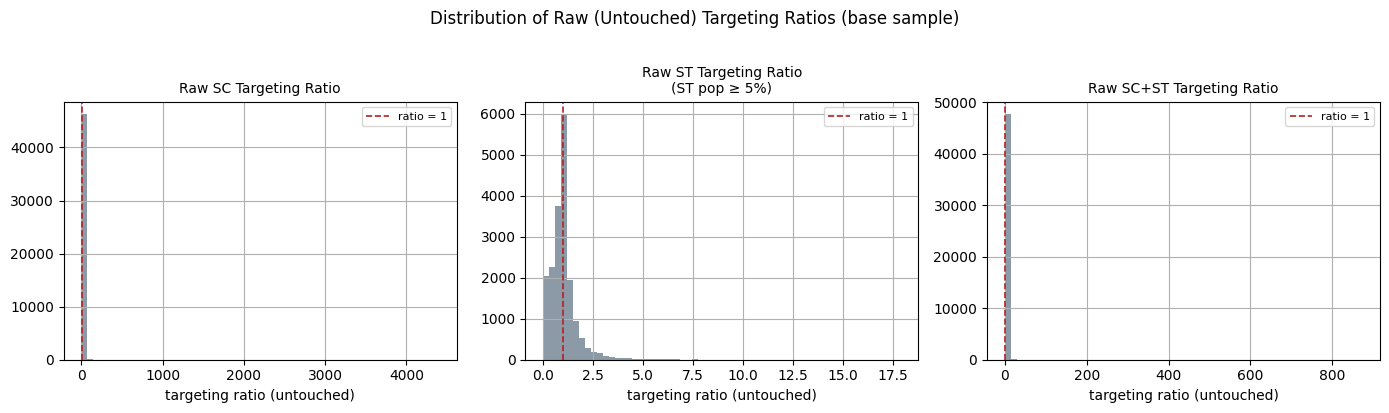

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
specs = [
    ('sc_targeting_ratio',   df_base, 'SC Targeting Ratio'),
    ('st_targeting_ratio',   df_st,   f'ST Targeting Ratio\n(ST pop ≥ {ST_floor*100:.0f}%)'),
    ('scst_targeting_ratio', df_base, 'SC+ST Targeting Ratio'),
]

for ax, (var, src, title) in zip(axes, specs):
    src[var].dropna().hist(bins=60, ax=ax, color='slategrey', alpha=0.8, edgecolor='none')
    ax.axvline(1, color='firebrick', linestyle='--', linewidth=1.2, label='ratio = 1')
    ax.set_title(f'Raw {title}', fontsize=10)
    ax.set_xlabel('targeting ratio (untouched)')
    ax.legend(fontsize=8)

plt.suptitle('Distribution of Raw (Untouched) Targeting Ratios (base sample)', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()


### Winsorised targeting distributions

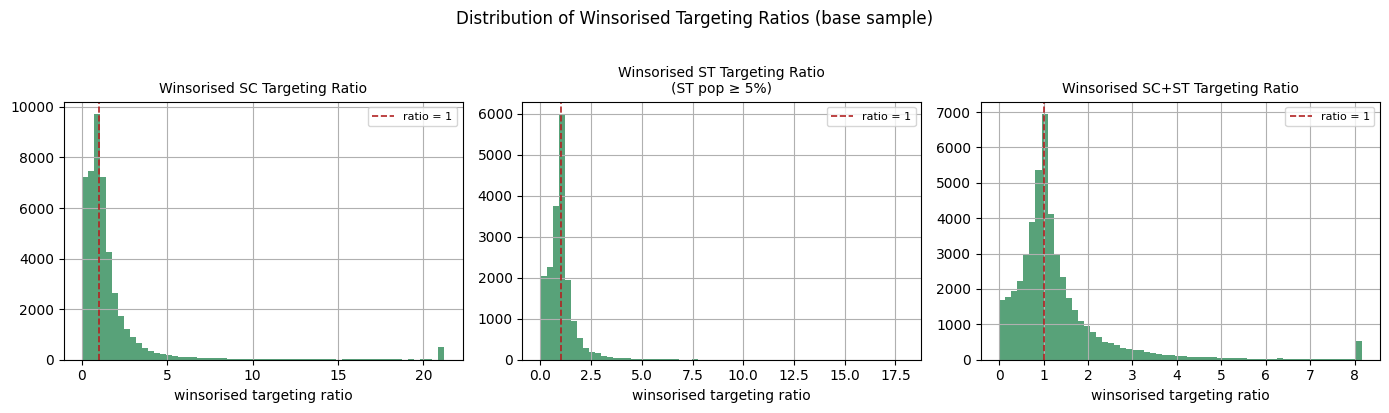

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
specs = [
    ('wins_sc_targeting',   df_base, 'SC Targeting Ratio'),
    ('wins_st_targeting',   df_st,   f'ST Targeting Ratio\n(ST pop ≥ {ST_floor*100:.0f}%)'),
    ('wins_scst_targeting', df_base, 'SC+ST Targeting Ratio'),
]

for ax, (var, src, title) in zip(axes, specs):
    src[var].dropna().hist(bins=60, ax=ax, color='seagreen', alpha=0.8, edgecolor='none')
    ax.axvline(1, color='firebrick', linestyle='--', linewidth=1.2, label='ratio = 1')
    ax.set_title(f'Winsorised {title}', fontsize=10)
    ax.set_xlabel('winsorised targeting ratio')
    ax.legend(fontsize=8)

plt.suptitle('Distribution of Winsorised Targeting Ratios (base sample)', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()


### Log-winsorised targeting distributions

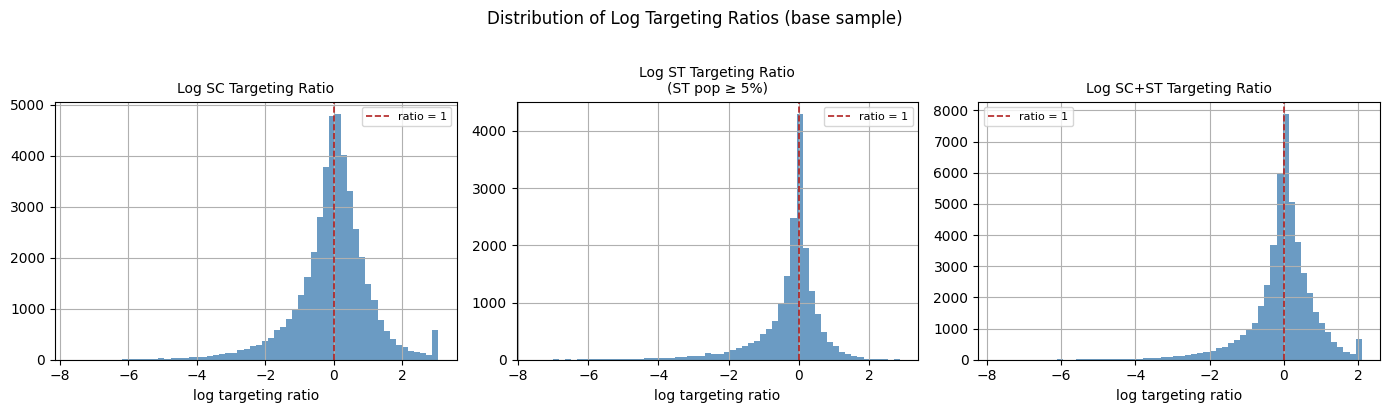

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
specs = [
    ('ln_sc_targeting',   df_base, 'SC Targeting Ratio'),
    ('ln_st_targeting',   df_st,   f'ST Targeting Ratio\n(ST pop ≥ {ST_floor*100:.0f}%)'),
    ('ln_scst_targeting', df_base, 'SC+ST Targeting Ratio'),
]

for ax, (var, src, title) in zip(axes, specs):
    src[var].dropna().hist(bins=60, ax=ax, color='steelblue', alpha=0.8, edgecolor='none')
    ax.axvline(0, color='firebrick', linestyle='--', linewidth=1.2, label='ratio = 1')
    ax.set_title(f'Log {title}', fontsize=10)
    ax.set_xlabel('log targeting ratio')
    ax.legend(fontsize=8)

plt.suptitle('Distribution of Log Targeting Ratios (base sample)', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/4. Outputs/targeting_ratio_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### Political competition treatment distributions

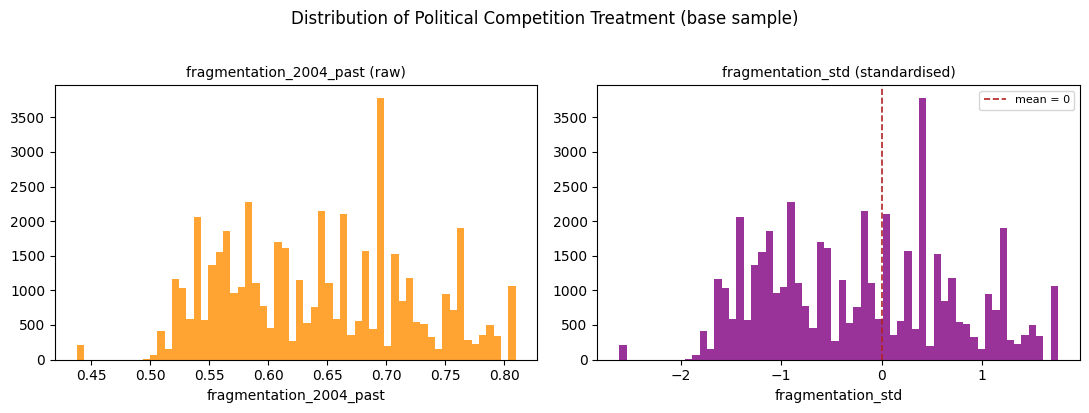

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(df_base['fragmentation_2004_past'].dropna(), bins=60,
             color='darkorange', alpha=0.8, edgecolor='none')
axes[0].set_title('fragmentation_2004_past (raw)', fontsize=10)
axes[0].set_xlabel('fragmentation_2004_past')

axes[1].hist(df_base['fragmentation_std'].dropna(), bins=60,
             color='purple', alpha=0.8, edgecolor='none')
axes[1].axvline(0, color='firebrick', linestyle='--', linewidth=1.2, label='mean = 0')
axes[1].set_title('fragmentation_std (standardised)', fontsize=10)
axes[1].set_xlabel('fragmentation_std')
axes[1].legend(fontsize=8)

plt.suptitle('Distribution of Political Competition Treatment (base sample)', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()


## Part 3: Regressions and Visualisations

### Regression helper

In [31]:
from linearmodels.iv.absorbing import AbsorbingLS

def run_absorbing_ols(data, outcome, controls=CONTROLS,
                      absorb_col='pc_dist', cluster_col='pc_dist'):
    """
    OLS with absorbed FE and clustered SEs.
    Returns (result, N).
    """
    use_cols = [outcome, 'fragmentation_std', absorb_col] + controls
    sub = data[use_cols].dropna().copy()
    sub[absorb_col] = sub[absorb_col].astype('category')

    exog = pd.concat(
        [pd.Series(1.0, index=sub.index, name='const'),
         sub[['fragmentation_std'] + controls]],
        axis=1
    )

    model = AbsorbingLS(
        dependent=sub[outcome],
        exog=exog,
        absorb=sub[[absorb_col]],
    )
    result = model.fit(cov_type='clustered', clusters=sub[cluster_col])
    return result, len(sub)


def result_row(res, n, label):
    coef  = res.params['fragmentation_std']
    se    = res.std_errors['fragmentation_std']
    tstat = res.tstats['fragmentation_std']
    pval  = res.pvalues['fragmentation_std']
    ci    = res.conf_int().loc['fragmentation_std']
    stars = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.10 else ''))
    return {
        'Outcome': label,
        'β': round(coef, 4),
        'SE': round(se, 4),
        't': round(tstat, 2),
        'p': round(pval, 3),
        'sig': stars,
        'CI 95%': f'[{ci["lower"]:.4f}, {ci["upper"]:.4f}]',
        'N': n,
    }

print('Running regressions...')

Running regressions...


### Main regressions — winsorised (non-log) outcomes

In [32]:
# Main regressions on the winsorised (non-log) targeting outcomes.
# Subsamples mirror the log specification.

sc_data_w   = df_base[df_base['wins_sc_targeting'].notna()].copy()
df_st_w     = df_base[(df_base['st_pop_share'] >= ST_floor) & df_base['wins_st_targeting'].notna()].copy()
scst_data_w = df_base[df_base['wins_scst_targeting'].notna()].copy()

res_sc_w,   n_sc_w   = run_absorbing_ols(sc_data_w,   'wins_sc_targeting')
res_st_w,   n_st_w   = run_absorbing_ols(df_st_w,     'wins_st_targeting')
res_scst_w, n_scst_w = run_absorbing_ols(scst_data_w, 'wins_scst_targeting')

print(f'=== Winsorised SC (N={n_sc_w:,}) ===')
print(res_sc_w.summary.tables[1])
print(f'\n=== Winsorised ST, ST pop ≥ {ST_floor*100:.0f}% (N={n_st_w:,}) ===')
print(res_st_w.summary.tables[1])
print(f'\n=== Winsorised SC+ST (N={n_scst_w:,}) ===')
print(res_scst_w.summary.tables[1])


=== Winsorised SC (N=46,496) ===
                                 Parameter Estimates                                  
                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------------
const                  4.8290     5.1037     0.9462     0.3441     -5.1740      14.832
fragmentation_std      0.0034     0.1002     0.0339     0.9729     -0.1931      0.1999
share_l6_past         -2.0460     11.633    -0.1759     0.8604     -24.845      20.753
share_lit_past        -1.2717     2.0290    -0.6268     0.5308     -5.2485      2.7051
poverty_pre66_past    -0.0797     0.4566    -0.1746     0.8614     -0.9747      0.8152
ln_population         -0.0740     0.3068    -0.2412     0.8094     -0.6754      0.5274
urbanization_past      0.2830     0.7294     0.3880     0.6980     -1.1466      1.7126
primary_past          -0.7178     0.9736    -0.7373     0.4609     -2.6260      1.1903
phc_past  

### Main regressions — log-winsorised outcomes

In [33]:
# (1) SC targeting
sc_data = df_base[df_base['ln_sc_targeting'].notna()].copy()
res_sc, n_sc = run_absorbing_ols(sc_data, 'ln_sc_targeting')
print(f'=== SC Targeting (N={n_sc:,}) ===')
print(res_sc.summary.tables[1])

=== SC Targeting (N=44,915) ===
                                 Parameter Estimates                                  
                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------------
const                  4.1360     2.0377     2.0297     0.0424      0.1421      8.1299
fragmentation_std     -0.0114     0.0418    -0.2735     0.7844     -0.0934      0.0705
share_l6_past         -0.3644     4.2287    -0.0862     0.9313     -8.6526      7.9238
share_lit_past         0.0102     0.7589     0.0135     0.9892     -1.4772      1.4977
poverty_pre66_past     0.1356     0.2419     0.5606     0.5751     -0.3385      0.6097
ln_population         -0.2448     0.1296    -1.8886     0.0589     -0.4989      0.0093
urbanization_past      0.4090     0.2656     1.5397     0.1236     -0.1116      0.9296
primary_past          -0.7120     0.4350    -1.6370     0.1016     -1.5646      0.1405
phc_past   

In [34]:
# (2) ST targeting (restricted: ST pop share >= 5%)
res_st, n_st = run_absorbing_ols(df_st, 'ln_st_targeting')
print(f'=== ST Targeting, ST pop ≥ 5% (N={n_st:,}) ===')
print(res_st.summary.tables[1])

=== ST Targeting, ST pop ≥ 5% (N=18,563) ===
                                 Parameter Estimates                                  
                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------------
const                  1.8225     5.1265     0.3555     0.7222     -8.2254      11.870
fragmentation_std      0.0318     0.1146     0.2771     0.7817     -0.1929      0.2564
share_l6_past          6.7350     6.4696     1.0410     0.2979     -5.9452      19.415
share_lit_past         1.0366     1.5177     0.6830     0.4946     -1.9380      4.0112
poverty_pre66_past    -0.0453     0.4016    -0.1128     0.9102     -0.8325      0.7419
ln_population         -0.1953     0.3594    -0.5436     0.5867     -0.8997      0.5090
urbanization_past      1.2548     0.5269     2.3814     0.0172      0.2220      2.2875
primary_past           0.0044     0.9215     0.0048     0.9962     -1.8018      1.810

In [35]:
# (3) SC+ST targeting
scst_data = df_base[df_base['ln_scst_targeting'].notna()].copy()
res_scst, n_scst = run_absorbing_ols(scst_data, 'ln_scst_targeting')
print(f'=== SC+ST Targeting (N={n_scst:,}) ===')
print(res_scst.summary.tables[1])

=== SC+ST Targeting (N=47,995) ===
                                 Parameter Estimates                                  
                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------------
const                  3.9009     1.8848     2.0696     0.0385      0.2066      7.5951
fragmentation_std     -0.0577     0.0398    -1.4517     0.1466     -0.1357      0.0202
share_l6_past         -0.2328     3.4485    -0.0675     0.9462     -6.9918      6.5261
share_lit_past         0.2217     0.6426     0.3450     0.7301     -1.0377      1.4811
poverty_pre66_past    -0.0077     0.1988    -0.0390     0.9689     -0.3974      0.3819
ln_population         -0.2426     0.1281    -1.8934     0.0583     -0.4938      0.0085
urbanization_past      0.4215     0.2060     2.0465     0.0407      0.0178      0.8251
primary_past          -0.6239     0.3519    -1.7731     0.0762     -1.3136      0.0658
phc_past

### Binscatter — log-winsorised outcomes

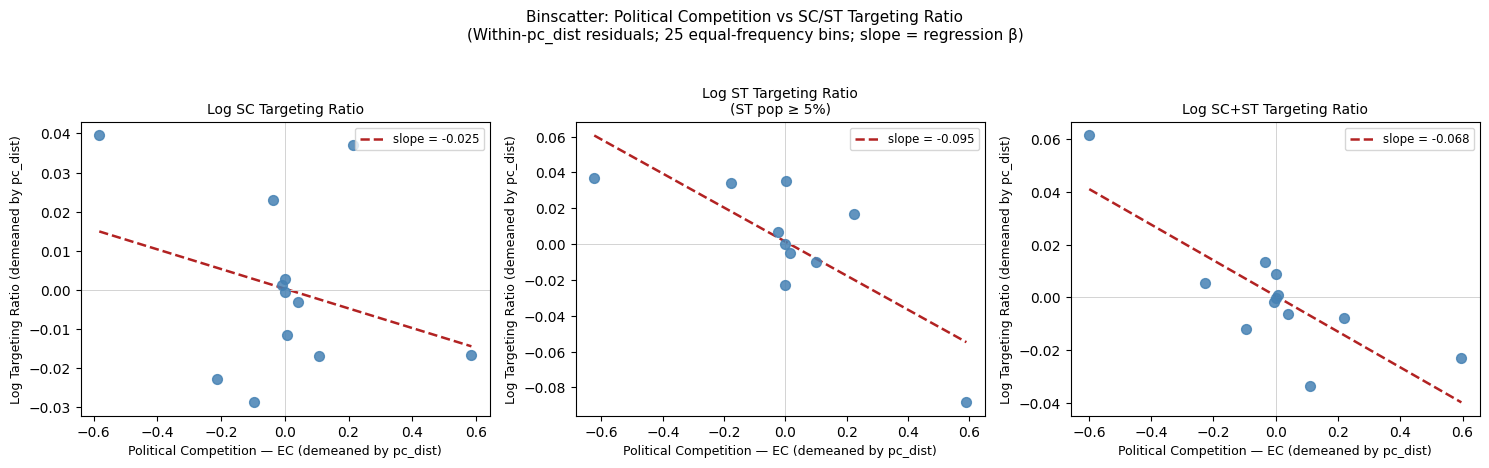

In [36]:
# VISUALISATION 1: Binscatter — political competition vs targeting ratio, within pc_dist FE
#
# A binscatter is the standard visual companion to a fixed-effects regression.
# Procedure:
#   1. Demean both X (fragmentation_std) and Y (ln_targeting) by pc_dist group means.
#      This is the within-transformation that absorbs the FE, exactly as in the regression.
#   2. Divide the demeaned X into 25 equal-frequency quantile bins.
#   3. Plot the mean of demeaned Y against the mean of demeaned X for each bin.
#   4. Overlay the OLS line through the binned means — its slope equals the regression β.
#
# A flat line = β ≈ 0 = no within-FE relationship between competition and targeting.

def binscatter(data, x_col, y_col, fe_col='pc_dist', n_bins=25, ax=None, color='steelblue'):
    sub = data[[x_col, y_col, fe_col]].dropna().copy()
    # Within-transform: subtract FE group means (equivalent to demeaning by FE dummies)
    sub['x_res'] = sub[x_col] - sub.groupby(fe_col)[x_col].transform('mean')
    sub['y_res'] = sub[y_col] - sub.groupby(fe_col)[y_col].transform('mean')
    # Bin into equal-count quantile bins
    sub['bin'] = pd.qcut(sub['x_res'], q=n_bins, duplicates='drop')
    binned = sub.groupby('bin', observed=True)[['x_res', 'y_res']].mean().reset_index()
    if ax is None:
        _, ax = plt.subplots()
    ax.scatter(binned['x_res'], binned['y_res'], s=50, color=color, alpha=0.85, zorder=3)
    coef = np.polyfit(binned['x_res'], binned['y_res'], 1)
    xr = np.linspace(binned['x_res'].min(), binned['x_res'].max(), 100)
    ax.plot(xr, np.polyval(coef, xr), color='firebrick', linewidth=1.8,
            linestyle='--', label=f'slope = {coef[0]:.3f}')
    ax.axhline(0, color='lightgrey', linewidth=0.7)
    ax.axvline(0, color='lightgrey', linewidth=0.7)
    ax.legend(fontsize=8.5)
    return ax

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
specs_bs = [
    ('ln_sc_targeting',   sc_data,   'Log SC Targeting Ratio'),
    ('ln_st_targeting',   df_st,     'Log ST Targeting Ratio\n(ST pop ≥ 5%)'),
    ('ln_scst_targeting', scst_data, 'Log SC+ST Targeting Ratio'),
]
for ax, (y, src, title) in zip(axes, specs_bs):
    binscatter(src, 'fragmentation_std', y, ax=ax)
    ax.set_xlabel('Political Competition — EC (demeaned by pc_dist)', fontsize=9)
    ax.set_ylabel('Log Targeting Ratio (demeaned by pc_dist)', fontsize=9)
    ax.set_title(title, fontsize=10)

plt.suptitle(
    'Binscatter: Political Competition vs SC/ST Targeting Ratio\n'
    '(Within-pc_dist residuals; 25 equal-frequency bins; slope = regression β)',
    fontsize=11, y=1.03
)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/4. Outputs/binscatter_ec_targeting.png', dpi=150, bbox_inches='tight')
plt.show()

### Binscatter — winsorised (non-log) outcomes

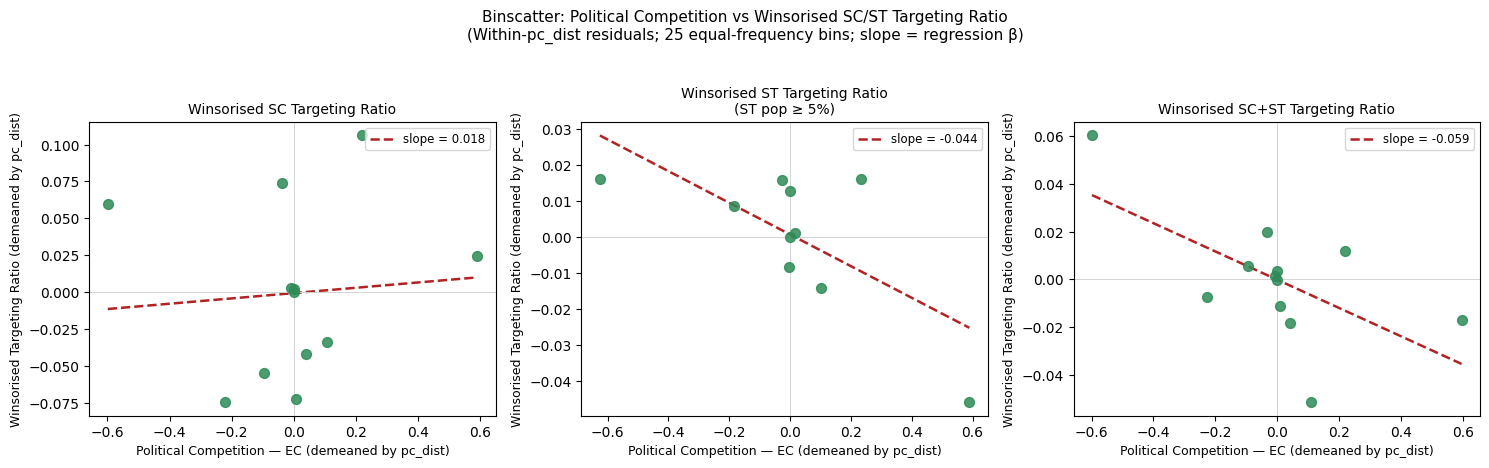

In [37]:
# Binscatter on the winsorised (non-log) targeting outcomes.
# Uses sc_data_w / df_st_w / scst_data_w from the winsorised regression cell above
# and `binscatter()` defined in the log binscatter cell.

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
specs_bs_w = [
    ('wins_sc_targeting',   sc_data_w,   'Winsorised SC Targeting Ratio'),
    ('wins_st_targeting',   df_st_w,     f'Winsorised ST Targeting Ratio\n(ST pop ≥ {ST_floor*100:.0f}%)'),
    ('wins_scst_targeting', scst_data_w, 'Winsorised SC+ST Targeting Ratio'),
]
for ax, (y, src, title) in zip(axes, specs_bs_w):
    binscatter(src, 'fragmentation_std', y, ax=ax, color='seagreen')
    ax.set_xlabel('Political Competition — EC (demeaned by pc_dist)', fontsize=9)
    ax.set_ylabel('Winsorised Targeting Ratio (demeaned by pc_dist)', fontsize=9)
    ax.set_title(title, fontsize=10)

plt.suptitle(
    'Binscatter: Political Competition vs Winsorised SC/ST Targeting Ratio\n'
    '(Within-pc_dist residuals; 25 equal-frequency bins; slope = regression β)',
    fontsize=11, y=1.03
)
plt.tight_layout()
plt.show()


### Heterogeneity binscatter — by population-share tercile

In [ ]:
# Binscatter that splits each outcome's sample by population-share tercile and
# bins WITHIN tercile (smaller bins, more dots). Slope lines per tercile reveal
# whether the EC -> targeting relationship varies by share of caste population.

def binscatter_by_group(data, x_col, y_col, group_col, fe_col='pc_dist',
                          n_bins=20, ax=None, group_order=None, colors=None):
    """Binscatter with separate dots and slope lines per group."""
    if group_order is None:
        group_order = list(data[group_col].cat.categories) if hasattr(data[group_col], 'cat') \
                       else sorted(data[group_col].dropna().unique())
    if colors is None:
        colors = ['#3498db', '#9b59b6', '#e67e22']
    if ax is None:
        _, ax = plt.subplots()

    for grp, color in zip(group_order, colors):
        sub = data[data[group_col] == grp][[x_col, y_col, fe_col]].dropna().copy()
        if len(sub) < n_bins:
            continue
        sub['x_res'] = sub[x_col] - sub.groupby(fe_col)[x_col].transform('mean')
        sub['y_res'] = sub[y_col] - sub.groupby(fe_col)[y_col].transform('mean')
        sub['bin']   = pd.qcut(sub['x_res'], q=n_bins, duplicates='drop')
        binned = sub.groupby('bin', observed=True)[['x_res', 'y_res']].mean().reset_index()
        coef = np.polyfit(binned['x_res'], binned['y_res'], 1)
        ax.scatter(binned['x_res'], binned['y_res'], s=22, color=color, alpha=0.75, zorder=3,
                   label=f'{grp} (N={len(sub):,}, slope={coef[0]:+.3f})')
        xr = np.linspace(binned['x_res'].min(), binned['x_res'].max(), 100)
        ax.plot(xr, np.polyval(coef, xr), color=color, linewidth=1.5, linestyle='--', alpha=0.85)

    ax.axhline(0, color='lightgrey', linewidth=0.7)
    ax.axvline(0, color='lightgrey', linewidth=0.7)
    ax.legend(fontsize=8, loc='best')
    return ax

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
specs_het = [
    ('ln_sc_targeting',   sc_data,   'sc_tercile',   'Log SC Targeting',                    'SC pop share'),
    ('ln_st_targeting',   df_st,     'st_tercile',   f'Log ST Targeting (ST pop ≥ {ST_floor*100:.0f}%)', 'ST pop share'),
    ('ln_scst_targeting', scst_data, 'scst_tercile', 'Log SC+ST Targeting',                 'SC+ST pop share'),
]
for ax, (y, src, group, title, share_label) in zip(axes, specs_het):
    binscatter_by_group(src, 'fragmentation_std', y, group_col=group, n_bins=20, ax=ax)
    ax.set_xlabel('Political Competition — EC (demeaned by pc_dist)', fontsize=9)
    ax.set_ylabel('Log Targeting Ratio (demeaned by pc_dist)', fontsize=9)
    ax.set_title(f'{title}\n(coloured by {share_label} tercile)', fontsize=10)

plt.suptitle(
    'Heterogeneity Binscatter: Political Competition vs SC/ST Targeting by Population-Share Tercile\n'
    '(20 bins per tercile; slope = within-tercile β)',
    fontsize=11, y=1.05
)
plt.tight_layout()
plt.show()


### Heterogeneity regressions — by population-share tercile

In [ ]:
# Run the main spec separately within each tercile of the relevant population
# share. Nine regressions total: 3 outcomes x 3 terciles. Within-tercile FE
# (pc_dist) absorption may have small cell sizes — flag if N gets very low.

het_specs = [
    ('SC',    'ln_sc_targeting',   sc_data,   'sc_tercile'),
    ('ST',    'ln_st_targeting',   df_st,     'st_tercile'),
    ('SC+ST', 'ln_scst_targeting', scst_data, 'scst_tercile'),
]

het_records = []
for outcome_label, y_col, frame, tercile_col in het_specs:
    print(f'\n=== {outcome_label} terciles ===')
    for tercile in TERCILE_LABELS:
        sub = frame[frame[tercile_col] == tercile].copy()
        res, n = run_absorbing_ols(sub, y_col)
        beta = res.params['fragmentation_std']
        se   = res.std_errors['fragmentation_std']
        pval = res.pvalues['fragmentation_std']
        ci   = res.conf_int().loc['fragmentation_std']
        stars = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.10 else ''))
        het_records.append({
            'Outcome': outcome_label, 'Tercile': tercile, 'N': n,
            'β': beta, 'SE': se, 'p': pval,
            'CI lo': ci['lower'], 'CI hi': ci['upper'],
            'sig': stars, '_res': res,
        })
        print(f'  {tercile:5s}: β = {beta:+.4f}  SE = {se:.4f}  N = {n:>6,}  p = {pval:.3f}  {stars}')

het_df = pd.DataFrame(het_records).drop(columns=['_res'])
print()
print('=== Summary table ===')
print(het_df.to_string(index=False))


### Coefficient plot — β across population-share terciles

In [ ]:
# Forest plot: β with 95% CI for each outcome × tercile cell.

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
TERCILE_COLORS = {'Low': '#3498db', 'Med': '#9b59b6', 'High': '#e67e22'}

for ax, outcome in zip(axes, ['SC', 'ST', 'SC+ST']):
    sub = het_df[het_df['Outcome'] == outcome].set_index('Tercile').loc[TERCILE_LABELS]
    y_pos = list(range(len(TERCILE_LABELS)))

    for i, tercile in enumerate(TERCILE_LABELS):
        beta = sub.loc[tercile, 'β']
        lo   = sub.loc[tercile, 'CI lo']
        hi   = sub.loc[tercile, 'CI hi']
        ax.errorbar(beta, i,
                    xerr=[[beta - lo], [hi - beta]],
                    fmt='o', color=TERCILE_COLORS[tercile], ecolor=TERCILE_COLORS[tercile],
                    capsize=5, markersize=8, linewidth=1.6)

    ax.axvline(0, color='grey', linestyle='--', linewidth=1)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([f'{t}\n(N={int(sub.loc[t, "N"]):,})' for t in TERCILE_LABELS], fontsize=9)
    ax.set_xlabel('β (1-SD increase in EC)', fontsize=10)
    ax.set_title(f'{outcome} targeting', fontsize=10)

plt.suptitle(
    'Effect of Political Competition on SC/ST Targeting, by Population-Share Tercile\n'
    '(95% CI, SEs clustered at pc_dist)',
    fontsize=11, y=1.03
)
plt.tight_layout()
plt.show()


### Reshuffled vs Non-Reshuffled GPs

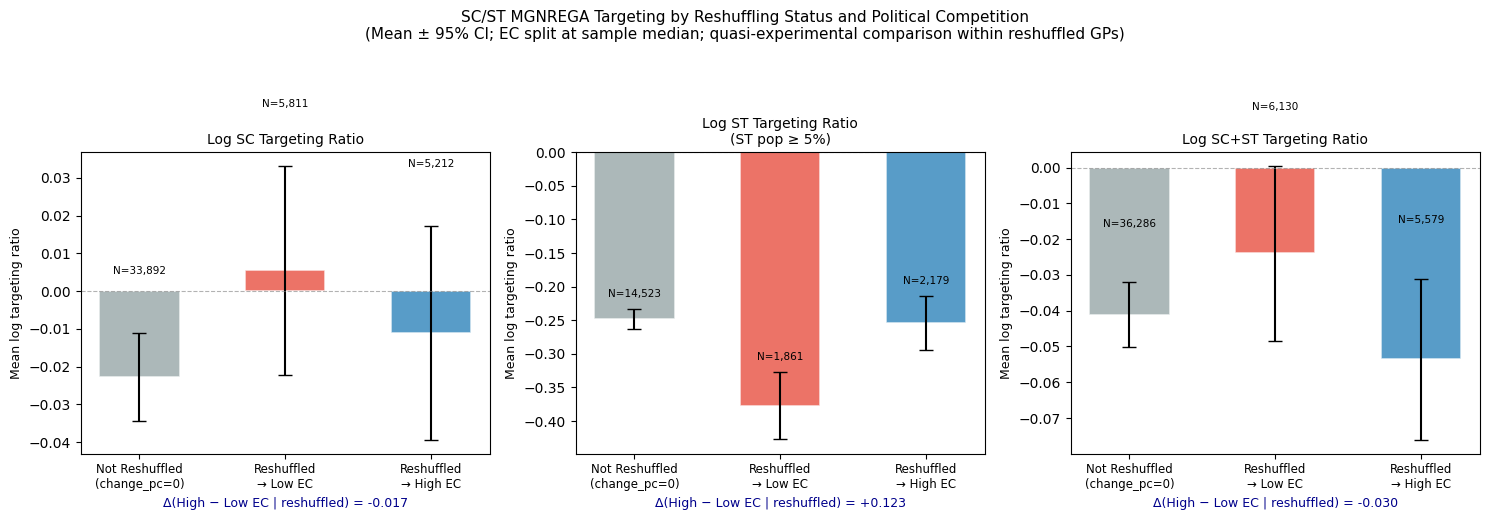

In [38]:
# VISUALISATION 2: Reshuffled vs Non-Reshuffled GPs
#
# The quasi-experiment assigns GPs within the same pre-delim PC to different post-delim
# PCs with different competition levels. `change_pc == 1` flags GPs whose constituency
# boundary actually changed (reshuffled). Among reshuffled GPs, which post-delim PC they
# landed in is plausibly quasi-random — that's Kjelsrud's identification claim.
#
# Groups:
#   Not Reshuffled (change_pc=0):  reference — GP stayed in similar PC
#   Reshuffled → Low EC:           moved to a LESS competitive post-delim PC
#   Reshuffled → High EC:          moved to a MORE competitive post-delim PC
#
# The key comparison is Low EC vs High EC WITHIN reshuffled GPs. Differences there
# are driven by the quasi-random assignment, not selection.

def assign_group(row, ec_median):
    if row['change_pc'] != 1:
        return 'Not Reshuffled\n(change_pc=0)'
    return 'Reshuffled\n→ High EC' if row['fragmentation_std'] >= ec_median else 'Reshuffled\n→ Low EC'

GROUP_ORDER  = ['Not Reshuffled\n(change_pc=0)', 'Reshuffled\n→ Low EC', 'Reshuffled\n→ High EC']
GROUP_COLORS = ['#95a5a6', '#e74c3c', '#2980b9']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
specs_rc = [
    ('ln_sc_targeting',   sc_data,   'Log SC Targeting Ratio'),
    ('ln_st_targeting',   df_st,     f'Log ST Targeting Ratio\n(ST pop ≥ {ST_floor*100:.0f}%)'),
    ('ln_scst_targeting', scst_data, 'Log SC+ST Targeting Ratio'),
]

for ax, (y, src, title) in zip(axes, specs_rc):
    src2 = src[src[y].notna()].copy()
    ec_med = src2['fragmentation_std'].median()
    src2['group'] = src2.apply(lambda r: assign_group(r, ec_med), axis=1)

    means = src2.groupby('group')[y].mean()
    sems  = src2.groupby('group')[y].sem()
    ns    = src2.groupby('group')[y].count()

    for i, (grp, col) in enumerate(zip(GROUP_ORDER, GROUP_COLORS)):
        if grp in means.index:
            ax.bar(i, means[grp], color=col, alpha=0.78, width=0.55,
                   yerr=sems[grp] * 1.96, capsize=5, edgecolor='white', linewidth=1.2)
            ax.text(i, means[grp] + sems[grp] * 1.96 + 0.015,
                    f'N={ns[grp]:,}', ha='center', va='bottom', fontsize=7.5)

    ax.set_xticks(range(len(GROUP_ORDER)))
    ax.set_xticklabels(GROUP_ORDER, fontsize=8.5)
    ax.set_ylabel('Mean log targeting ratio', fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.axhline(0, color='grey', linewidth=0.8, linestyle='--', alpha=0.6)

    # Annotate the quasi-experimental treatment effect (High − Low EC among reshuffled)
    if ('Reshuffled\n→ High EC' in means.index) and ('Reshuffled\n→ Low EC' in means.index):
        diff = means['Reshuffled\n→ High EC'] - means['Reshuffled\n→ Low EC']
        ax.set_xlabel(f'Δ(High − Low EC | reshuffled) = {diff:+.3f}', fontsize=9, color='darkblue')

plt.suptitle(
    'SC/ST MGNREGA Targeting by Reshuffling Status and Political Competition\n'
    '(Mean ± 95% CI; EC split at sample median; quasi-experimental comparison within reshuffled GPs)',
    fontsize=11, y=1.03
)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/4. Outputs/treatment_control_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Coefficient plot — all specifications

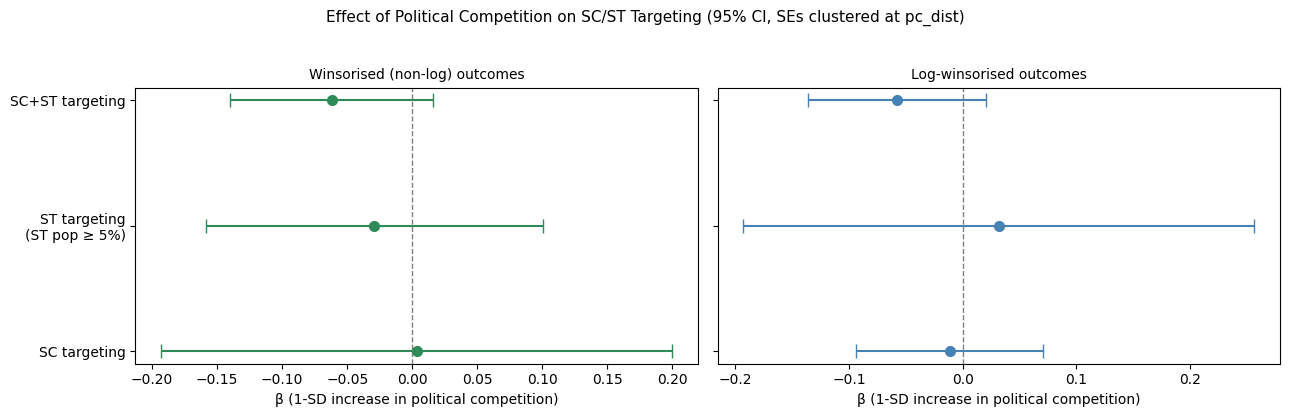

In [39]:
# Forest-style coefficient plot for the EC coefficient across all six regressions.
# Two panels because units differ between the winsorised (level) and log specifications.

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

labels = ['SC targeting', 'ST targeting\n(ST pop ≥ 5%)', 'SC+ST targeting']
y_pos  = list(range(len(labels)))

def _plot_panel(ax, results, color, panel_title):
    coefs = [r.params['fragmentation_std'] for r in results]
    lo    = [r.conf_int().loc['fragmentation_std', 'lower'] for r in results]
    hi    = [r.conf_int().loc['fragmentation_std', 'upper'] for r in results]
    ax.errorbar(coefs, y_pos,
                xerr=[np.array(coefs) - np.array(lo), np.array(hi) - np.array(coefs)],
                fmt='o', color=color, ecolor=color, capsize=5, markersize=7, linewidth=1.5)
    ax.axvline(0, color='grey', linestyle='--', linewidth=1)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlabel('β (1-SD increase in political competition)', fontsize=10)
    ax.set_title(panel_title, fontsize=10)

_plot_panel(axes[0], [res_sc_w, res_st_w, res_scst_w], 'seagreen', 'Winsorised (non-log) outcomes')
_plot_panel(axes[1], [res_sc,   res_st,   res_scst],   'steelblue', 'Log-winsorised outcomes')

plt.suptitle('Effect of Political Competition on SC/ST Targeting (95% CI, SEs clustered at pc_dist)',
             fontsize=11, y=1.03)
plt.tight_layout()
plt.show()


### Sampling distribution of coefficient estimates

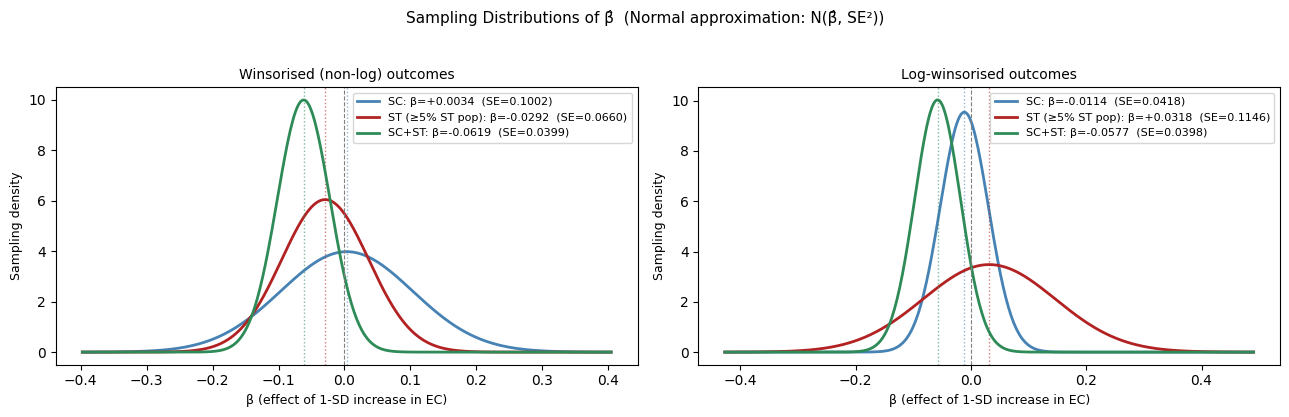

In [40]:
# Normal approximation to each estimator's sampling distribution: N(β̂, SE²).
# Centre = point estimate; spread = uncertainty; overlap with 0 = significance visual.

from scipy.stats import norm

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

specs_w = [(res_sc_w,   'SC',                              'steelblue'),
           (res_st_w,   f'ST (≥{ST_floor*100:.0f}% ST pop)', 'firebrick'),
           (res_scst_w, 'SC+ST',                           'seagreen')]
specs_l = [(res_sc,     'SC',                              'steelblue'),
           (res_st,     f'ST (≥{ST_floor*100:.0f}% ST pop)', 'firebrick'),
           (res_scst,   'SC+ST',                           'seagreen')]

for ax, specs, title in [(axes[0], specs_w, 'Winsorised (non-log) outcomes'),
                          (axes[1], specs_l, 'Log-winsorised outcomes')]:
    coefs = [r.params['fragmentation_std']     for r, _, _ in specs]
    ses   = [r.std_errors['fragmentation_std'] for r, _, _ in specs]
    xmin  = min(c - 4*s for c, s in zip(coefs, ses))
    xmax  = max(c + 4*s for c, s in zip(coefs, ses))
    x = np.linspace(xmin, xmax, 400)
    for r, label, color in specs:
        beta = r.params['fragmentation_std']
        se   = r.std_errors['fragmentation_std']
        ax.plot(x, norm.pdf(x, loc=beta, scale=se),
                color=color, linewidth=2,
                label=f'{label}: β={beta:+.4f}  (SE={se:.4f})')
        ax.axvline(beta, color=color, linestyle=':', linewidth=1, alpha=0.6)
    ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('β (effect of 1-SD increase in EC)', fontsize=9)
    ax.set_ylabel('Sampling density', fontsize=9)
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle('Sampling Distributions of β̂  (Normal approximation: N(β̂, SE²))',
             fontsize=11, y=1.03)
plt.tight_layout()
plt.show()
